# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# 1. Inicializar PySpark y Cargar los datos
spark = SparkSession.builder.appName("EDA_Fraud").getOrCreate()
df = spark.read.csv("../data/raw/bank_fraud.csv", header=True, inferSchema=True)

# 2. Mostrar la estructura básica
print(f"Total de registros: {df.count()}")
df.printSchema()


Matplotlib is building the font cache; this may take a moment.
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/14 18:38:48 WARN Utils: Your hostname, zamallita-HP-Notebook, resolves to a loopback address: 127.0.1.1; using 192.168.100.40 instead (on interface wlp2s0)
26/06/14 18:38:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/14 18:38:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Total de registros: 1000000
root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- transaction_date: date (nullable = true)
 |-- transaction_time: timestamp (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night_transaction: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- city: string (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- customer_age: integer (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- account_age_years: double (nullable = true)
 |-- account_balance: double (nullable = true)
 |-- transaction_amount: double (nullable = true)
 |-- num_prev_transactions: integer (nullable = true)
 |-- transaction_freq_monthly: integer (nullable = true)
 |-- distance_from_home_km: double (nullable = true)
 |-- time_since_last_txn_hrs

+-------+------------------+------------------+------------------+
|summary|      customer_age|   account_balance|transaction_amount|
+-------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|
|   mean|         41.771678| 16594.25441989984|204.72466542000055|
| stddev|13.424588458641443|28171.460679976855| 459.5678020103498|
|    min|                18|             100.0|               1.0|
|    max|                85|          500000.0|           46129.6|
+-------+------------------+------------------+------------------+



/tmp/ipykernel_41728/1666710986.py:9: FutureWarning:                            

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="is_fraud", y="count", data=fraud_counts, palette="viridis")


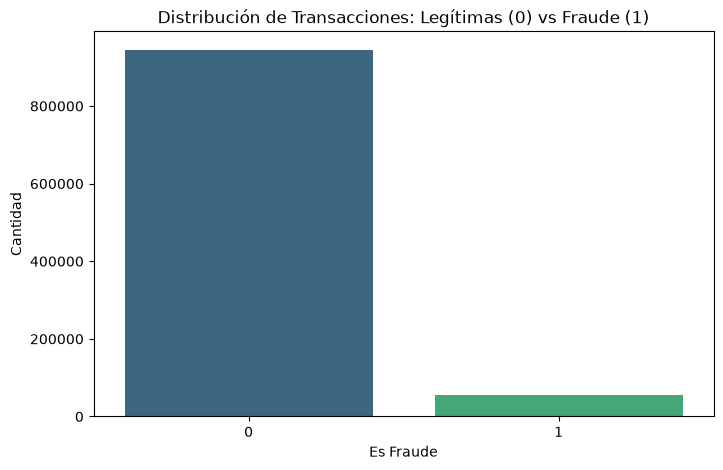

In [2]:
# 3. Estadísticas descriptivas simples para columnas numéricas
numeric_cols_sample = ["customer_age", "account_balance", "transaction_amount"]
df.select(numeric_cols_sample).describe().show()

# 4. Gráfico de Barras: Cantidad de Fraudes vs No Fraudes
fraud_counts = df.groupBy("is_fraud").count().toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(x="is_fraud", y="count", data=fraud_counts, palette="viridis")
plt.title("Distribución de Transacciones: Legítimas (0) vs Fraude (1)")
plt.xlabel("Es Fraude")
plt.ylabel("Cantidad")
plt.show()


In [3]:
# 5. Correlaciones con is_fraud
numeric_cols = [item[0] for item in df.dtypes if item[1] in ("int", "double", "float", "bigint")]

correlations = {}
for c in numeric_cols:
    if c != "is_fraud":
        try:
            val = df.stat.corr("is_fraud", c)
            correlations[c] = val
        except Exception as e:
            print(f"Failed for {c}: {e}")

sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]) if x[1] is not None else 0, reverse=True)

print("Correlaciones con is_fraud:")
for c, v in sorted_corr:
    print(f"{c}: {v}")


Correlaciones con is_fraud:
failed_attempts: 0.11654114485056916
is_night_transaction: 0.0824053638007112
is_international: 0.07962701493118007
hour_of_day: -0.03904593614982657
pin_changed_recently: 0.03674552610381068
transaction_amount: 0.012289893736120648
time_since_last_txn_hrs: -0.008909394089452667
credit_score: -0.005224392349526794
customer_age: -0.0029659073435415015
account_balance: 0.0016956250289543314
is_weekend: 0.0011898862683988602
num_prev_transactions: 0.001077252735011247
transaction_freq_monthly: 0.00041328087734303267
distance_from_home_km: -0.0003646128425506327
account_age_years: 7.780471684852623e-05
